In [1]:
## import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import timedelta

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


In [2]:
## Load required datasets
customers = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Customers.csv")
orders = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Orders.csv")
order_items = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\OrderItems.csv")

In [3]:
## prepare the data

#convert the order date into datetime format.
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [4]:
## check datatypes
orders.dtypes

order_id                           object
customer_id                        object
order_date                 datetime64[ns]
order_status                       object
channel                            object
order_priority                     object
coupon_used                         int64
coupon_discount_pct               float64
delivery_days_actual                int64
delivery_days_estimated             int64
dtype: object

In [5]:
#calculate Monetary value of each order
##total order value
order_value = (
    order_items.groupby('order_id')['line_revenue']
    .sum()
    .reset_index()
    .rename(columns={'line_revenue': 'order_value'})
)

order_value.head()

,order_id,order_value
0,ORD0000001,39332.21
1,ORD0000002,8563.86
2,ORD0000003,6764.87
3,ORD0000004,4383.32
4,ORD0000005,21863.11


In [6]:
#merge order values
orders_rfm = orders.merge(order_value, on='order_id')

#check
orders_rfm.head()

,order_id,customer_id,order_date,order_status,channel,order_priority,coupon_used,coupon_discount_pct,delivery_days_actual,delivery_days_estimated,order_value
0,ORD0000001,CUST001996,2022-03-18 15:15:14,Delivered,Website,Low,0,0.00,4,4,39332.21
1,ORD0000002,CUST010311,2021-12-19 00:19:11,Delivered,App,Low,1,30.94,1,1,8563.86
2,ORD0000003,CUST020207,2021-12-30 01:01:47,Delivered,Website,Low,0,0.00,4,2,6764.87
3,ORD0000004,CUST016230,2021-09-03 06:15:55,Delivered,App,High,0,0.00,11,11,4383.32
4,ORD0000005,CUST013548,2021-12-29 05:21:56,Delivered,Website,Medium,0,0.00,2,1,21863.11


In [7]:
#calculate recency relative to a reference date
snapshot_date = orders_rfm['order_date'].max() + timedelta(days=1)

print(snapshot_date)

2024-04-15 23:49:37


In [8]:
missing_customers = set(customers['customer_id']) - set(orders_rfm['customer_id'])

print("Missing customers:", len(missing_customers))


Missing customers: 267


In [9]:
customers[
    customers['customer_id'].isin(missing_customers)
].head()

,customer_id,customer_gender,customer_age,customer_state,customer_city,customer_pincode,signup_date,customer_segment,preferred_device,preferred_payment
12,CUST000013,Female,48,Dl,Delhi,260017,2024-07-09,Gold,Android,Upi
183,CUST000184,Female,32,Ka,Bengaluru,455051,2025-10-11,Bronze,Web,Upi
185,CUST000186,Female,30,Tn,Coimbatore,747543,2022-08-19,Silver,Web,Credit Card
203,CUST000204,Female,50,Ts,Hyderabad,971112,2020-05-16,Gold,Android,Net Banking
224,CUST000225,Female,58,Tn,Chennai,783130,2023-08-10,Gold,Android,Wallet


In [10]:
##calculate rfm table
rfm = orders_rfm.groupby('customer_id').agg(
    {
        'order_date' : lambda x : (snapshot_date - x.max()).days, #day since the customer's last purchase
        'order_id' : 'nunique',     # Number of unique orders
        'order_value' : 'sum'      #total_amount_spent on each order
    }
).reset_index()

#rename the columns 
rfm.columns = [
    'customer_id', 'Recency', 'Frequency', 'Monetary'
]

In [11]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST000001,85,4,191442.25
1,CUST000002,764,1,30402.66
2,CUST000003,119,4,97152.48
3,CUST000004,341,4,154460.99
4,CUST000005,645,5,211168.39


In [12]:
# basic statistics
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,24733.00,24733.00,24733.00
mean,252.49,4.59,161570.10
std,232.97,2.08,90323.79
min,1.00,1.00,236.11
25%,76.00,3.00,94660.66
50%,181.00,4.00,149353.89
75%,361.00,6.00,215040.61
max,1200.00,14.00,703931.10


In [13]:
# assign recency score
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels = [5,4,3,2,1]
).astype(int)

#assign frequency score
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method = 'first'),   #used .rank(method= 'first') to avoid error if many customers have the same frequency
    q=5,
    labels = [1,2,3,4,5]
).astype(int)

#assing monetary score
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    q = 5,
    labels = [1,2,3,4,5]
).astype(int)

In [14]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,CUST000001,85,4,191442.25,4,2,4
1,CUST000002,764,1,30402.66,1,1,1
2,CUST000003,119,4,97152.48,4,2,2
3,CUST000004,341,4,154460.99,2,2,3
4,CUST000005,645,5,211168.39,1,3,4


In [15]:
## create overall RFM score
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [16]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >=4 and row['M_score'] >=4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 4:
        return 'Loyal Customers'

    elif row['R_score'] >= 4 and row['F_score'] >= 2:
        return 'Potential Loyalists'

    elif row['R_score'] >= 4 and row['F_score'] == 1:
        return 'New Customers'

    elif row['R_score'] <= 2 and row['F_score'] >= 4:
        return 'At Risk'

    elif row['R_score'] == 1 and row['F_score'] >= 4:
        return "Can't Lose Them"

    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost Customers'

    else:
        return 'Others'

In [17]:
rfm['Customer_segment'] = rfm.apply(segment_customer, axis = 1)

In [18]:
rfm['Customer_segment'].value_counts()

Customer_segment
Lost Customers         5479
Others                 4705
Champions              4100
Potential Loyalists    3579
Loyal Customers        3337
At Risk                2456
New Customers          1077
Name: count, dtype: int64

In [19]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Customer_segment
0,CUST000001,85,4,191442.25,4,2,4,424,Potential Loyalists
1,CUST000002,764,1,30402.66,1,1,1,111,Lost Customers
2,CUST000003,119,4,97152.48,4,2,2,422,Potential Loyalists
3,CUST000004,341,4,154460.99,2,2,3,223,Lost Customers
4,CUST000005,645,5,211168.39,1,3,4,134,Others


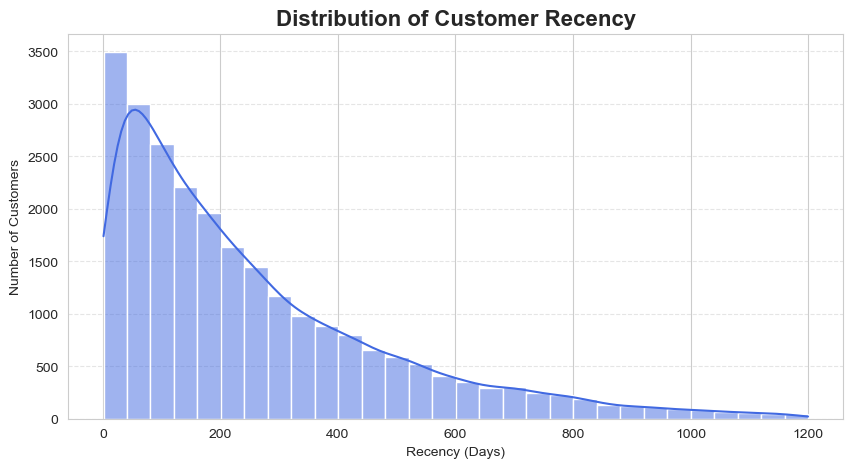

In [20]:
## Rfm segmentation analysis
#Q1 How are customers distributed acorss different recency values?
# Recency measures how recently customers made a purchase.
# helps identify whether most customers are active or have not purchased recently.

plt.figure(figsize=(10,5))

sns.histplot(
    rfm['Recency'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of Customer Recency",fontsize= 16, fontweight = "bold")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

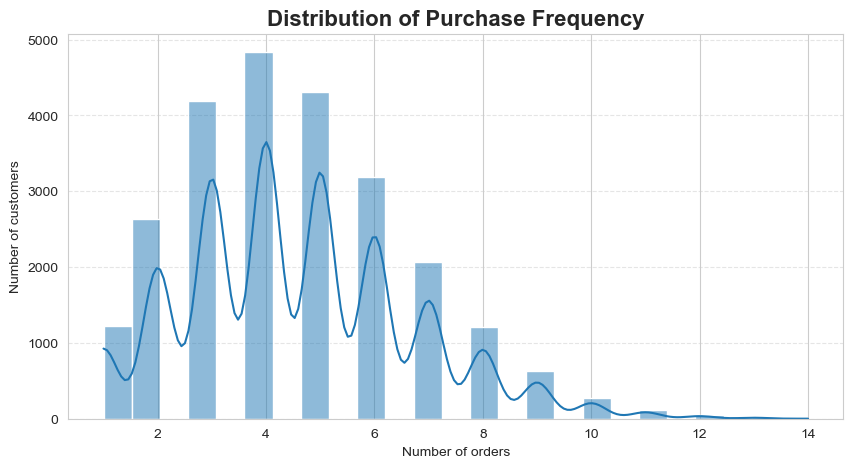

In [21]:
#Q2 How frequently do customers place orders?
# Frequency indicates customer loyalty.
# Customers who purchase more often contribute to stable revenue and should be retained.

plt.figure(figsize= (10,5))

sns.histplot(
    rfm['Frequency'],
    bins = 25,
    kde= True
)

plt.title("Distribution of Purchase Frequency", fontsize= 16, fontweight="bold")
plt.xlabel("Number of orders")
plt.ylabel("Number of customers")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()
# If there are no customers with certain frequency values, those bins will be empty, which appears as a gap.

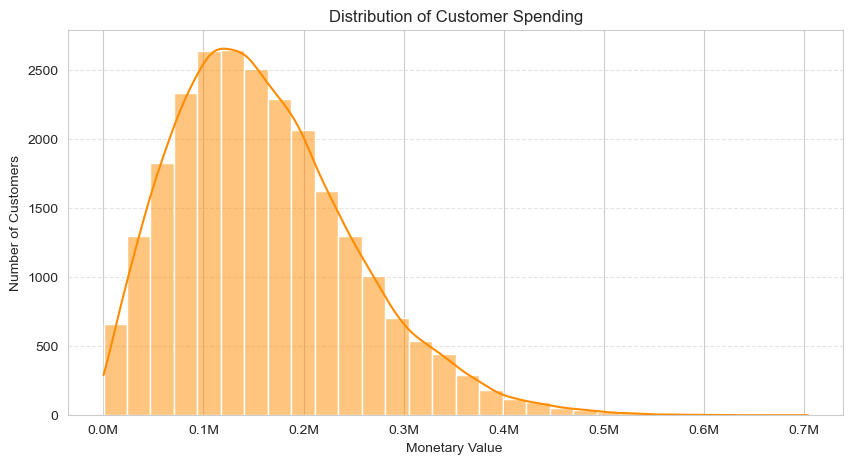

In [22]:
#Q3 How much do customers spend overall?
# Monetary value measures customer spending. 
# This helps distinguish high-value customers from occasional buyers.

plt.figure(figsize=(10,5))

ax = sns.histplot(
    rfm['Monetary'],
    bins=30,
    kde=True,
    color='darkorange'
)

import matplotlib.ticker as ticker

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M')
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Monetary Value ")
plt.ylabel("Number of Customers")


plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4224\3298475142.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


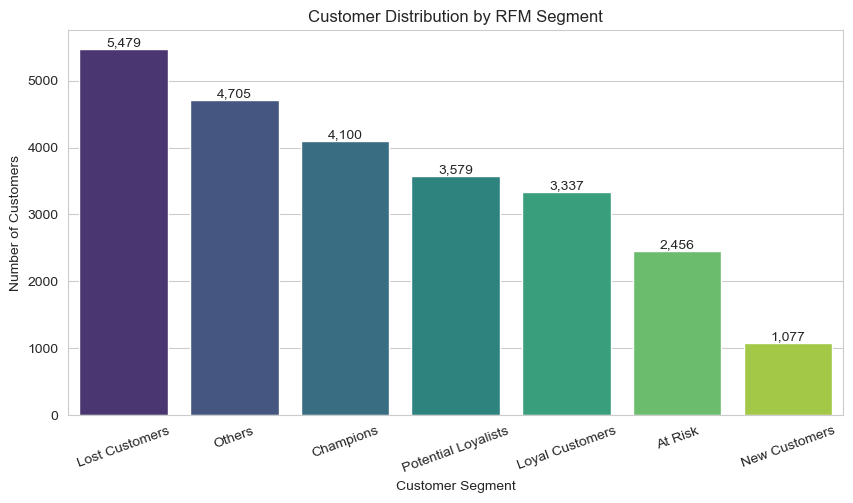

In [23]:
#Q4 How are customers distributed across RFM segments?
# This identifies the proportion of customers in each business segment, helping prioritize retention and marketing strategies.

segment_count = (
    rfm['Customer_segment']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=segment_count.index,
    y=segment_count.values,
    palette='viridis'
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

for i, v in enumerate(segment_count.values):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=10)

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4224\2423995766.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


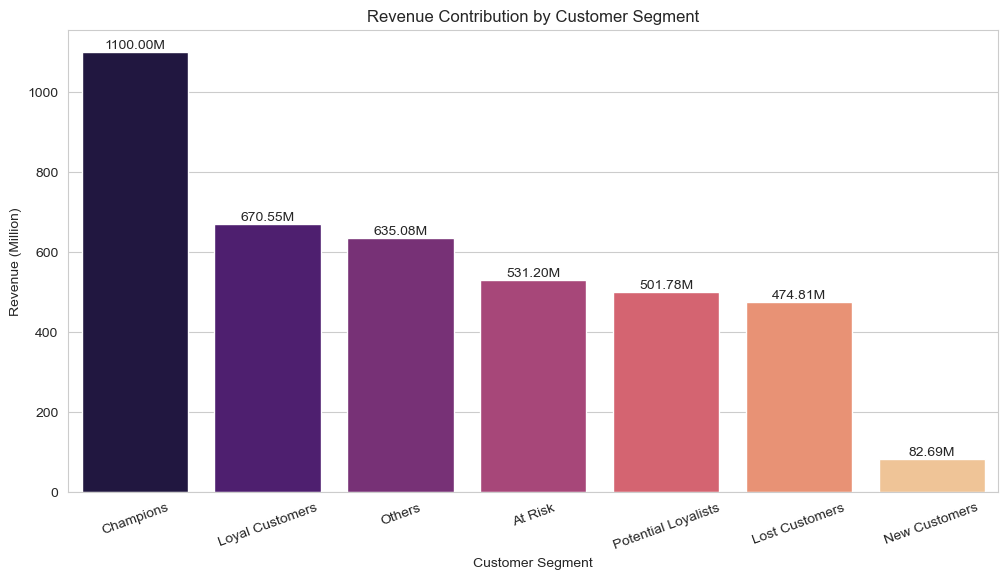

In [24]:
#Q5 Which customer segments contribute the highest revenue?
# Understanding revenue contribution by segment helps businesses allocate marketing budgets effectively.

segment_revenue = (
    rfm.groupby('Customer_segment')['Monetary']
       .sum()
       .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values/1e6,
    palette='magma'
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (Million)")

plt.xticks(rotation=20)

for i, v in enumerate(segment_revenue.values/1e6):
    ax.text(i, v, f"{v:.2f}M", ha='center', va='bottom')

plt.show()

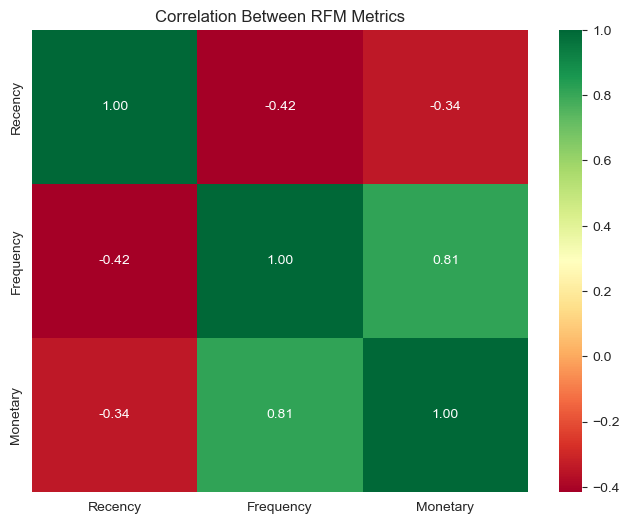

In [25]:
#Q6 Is there any relationship between Recency, Frequency, and Monetary value?
# A correlation analysis reveals how customer purchase behavior metrics relate to each other.

plt.figure(figsize=(8,6))

corr = rfm[['Recency','Frequency','Monetary']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f'
)

plt.title("Correlation Between RFM Metrics")

plt.show()

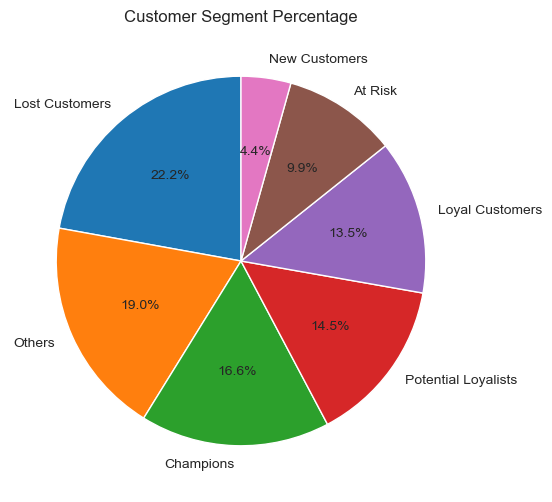

In [26]:
#Q7 What percentage of customers belong to each RFM segment?
# Understanding segment proportions helps businesses estimate the size of each customer group and plan targeted campaigns.

segment_percent = (
    rfm['Customer_segment']
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(6,6))

plt.pie(
    segment_percent,
    labels=segment_percent.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Segment Percentage")

plt.show()

In [27]:
rfm.to_csv("D:\Flipkart sales analytics\cleaned_dataset\RFM_Segmentation.csv", index=False)

print("RFM Segmentation dataset exported successfully.")

RFM Segmentation dataset exported successfully.
